#### *Imports*

In [4]:
import pandas as pd
import torch
import torch.nn as nn 
import torch.optim as optim
import matplotlib.pyplot as plt
import helper_funtions

#### *1 - Multi-Feature Data*

#### *1.1 - Loading and Exploring the Raw Data*


In [2]:
# Load the dataset from the CSV file
file_path = "./data_with_features.csv"
data_df = pd.read_csv(file_path)

# Print the shape of the DataFrame
print(f"Dataset Shape: {data_df.shape}\n")

Dataset Shape: (100, 4)



In [3]:
# Set the number of rows you want to display
row_to_display = 15

# Display the rows
print(data_df.head(row_to_display))

    distance_miles  time_of_day_hours  is_weekend  delivery_time_minutes
0             1.60               8.20           0                   7.22
1            13.09              16.80           1                  32.41
2             6.97               8.02           1                  17.47
3            10.66              16.07           0                  37.17
4            18.24              13.47           0                  38.36
5             5.74              16.59           0                  29.06
6             8.80              12.25           0                  23.94
7            15.36              11.76           1                  32.40
8             5.35               9.42           0                  17.06
9             2.46              14.44           0                  14.09
10            6.51               8.00           0                  33.38
11            4.06               9.33           1                  17.38
12           18.66              14.86           1  

The helper function, plot_delivery_data below will create a detailed scatter plot that visualizes all four features at once:

* The x-axis will represent the distance of the delivery.
* The y-axis will represent the delivery time.
* The color of each point will show the time of day, with lighter colors for earlier dispatches and darker reds for    later ones.
* The style of each point will indicate the day type, with solid circles for weekdays and hollow circles for weekends.

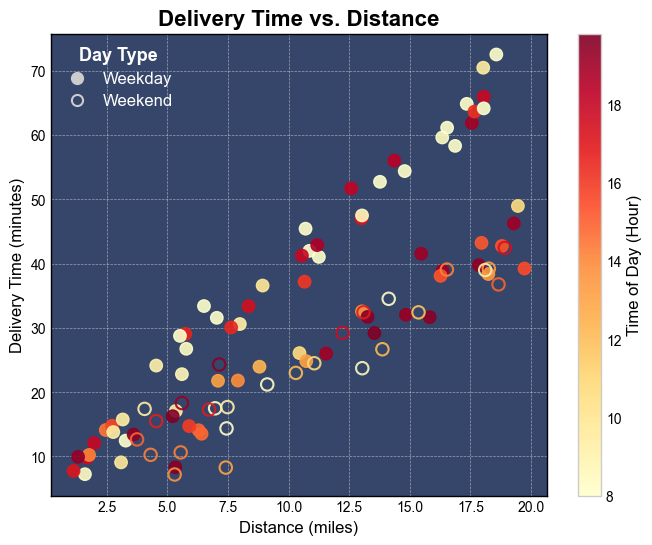

In [5]:
helper_funtions.plot_delivery_data(data_df)

#### *1.2 - Feature Engineering: Adding Rush Hour*

Before applying logic to the entire dataset, it's a good practice to work with a small sample. This allows to build and test function quickly.

Define the first 5 rows of data_df as a __PyTorch tensor__.
Use a tensor for this sample because the complete dataset will also be loaded as a tensor. This ensures that the function build now will work on the full dataset later without any changes.
This initial tensor contains all the data for each sample delivery.

In [6]:
# Define the 5 rows of data as a single 2D tensor
sample_tensor = torch.tensor([
    # distance, time_of_day, is_weekend, delivery_time
    [1.60,      8.20,        0,          7.22],   # row 1
    [13.09,     16.80,       1,          32.41],  # row 2       
    [6.97,      8.02,        1,          17.47],  # row 3
    [10.66,     16.07,       0,          37.17],  # row 4
    [18.24,     13.47,       0,          38.36]   # row 5
],dtype=torch.float32)

In [7]:
# Use tensor slicing to separate out each column
# Slicing syntax is [:, column_index]
sample_hours = sample_tensor[:,1]
sample_weekends = sample_tensor[:,2]

print("--- Sliced Tensors ---")
print(f"Sample Hours:    {sample_hours}")
print(f"Sample Weekends: {sample_weekends}\n")


--- Sliced Tensors ---
Sample Hours:    tensor([ 8.2000, 16.8000,  8.0200, 16.0700, 13.4700])
Sample Weekends: tensor([0., 1., 1., 0., 0.])



#### *Implement the rush_hour_feature function*
Task:

Define the individual conditions:
* Define is_morning_rush to be True where the hours_tensor is greater than or equal to 8.0 AND less than 10.0.
* Define is_evening_rush to be True where the hours_tensor is greater than or equal to 16.0 AND less than 19.0.
* Define is_weekday to be True where the weekends_tensor is equal to 0.

Combine the conditions:
* Define is_rush_hour_mask by combining the three boolean tensors. The logic should be True only if it's a weekday AND it's either morning rush OR evening rush.

In [8]:

def rush_hour_feature(hours_tensor,weekends_tensor):
    """
    This function creates a new binary feature indicating if a delivery is in a weekday rush hour.

    Args:
        hours_tensor (torch.Tensor): A tensor of delivery times of day.
        weekends_tensor (torch.Tensor): A tensor indicating if a delivery is on a weekend.

    Returns:
        torch.Tensor: A tensor of 0s and 1s indicating weekday rush hour.
    
    """

    # Define rush hour and weekday conditions
    is_morning_rush = (hours_tensor >= 8.0) & (hours_tensor < 10.0)
    is_evening_rush = (hours_tensor >= 16.0) & (hours_tensor < 19.0)
    is_weekday = weekends_tensor == 0

    # Combine the conditions to create the final rush hour mask
    is_rush_hour_mask = ((is_morning_rush | is_evening_rush) & is_weekday)

    # Convert the boolean mask to a float tensor to use as a numerical feature
    return is_rush_hour_mask.float()


In [9]:
rush_hour_for_sample = rush_hour_feature(sample_hours,sample_weekends)


print(f"Sample Hours: {sample_hours.numpy()}")
print(f"Sample Weekends: {sample_weekends.numpy()}")
print(f"Rush Hour: {rush_hour_for_sample.numpy()}")

Sample Hours: [ 8.2  16.8   8.02 16.07 13.47]
Sample Weekends: [0. 1. 1. 0. 0.]
Rush Hour: [1. 0. 0. 1. 0.]


#### *1.3 - Building the Data Preparation Pipeline*

In [13]:
def prepare_data(df):
    """
    Converts a pandas dataframe into prepared Pytorch tensors for modeling.

    Args:
        df (pd.DataFrame): A pandas DataFrame containing the raw delivery data.
    
    Returns:
        prepared_features (torch.Tensor): The 2D feature tensor for the model.
        prepared_targets (torch.Tensor): The 2D target tensor.
        results_dict (dict): A dictionary of intermediate tensors for testing purposes.
    
    """

    # Extract the data from the DataFrame as a NumPy array
    # (There's no direct torch.from_dataframe(), so we use .values to get a NumPy array first)
    all_values = df.values

    # Convert all the values from the DataFrame into a single PyTorch tensor
    full_tensor = torch.tensor(all_values,dtype=torch.float32)

    # Use tensor slicing to separate out each raw column
    raw_distances = full_tensor[:,0]
    raw_hours = full_tensor[:,1]
    raw_weekends = full_tensor[:,2]
    raw_targets = full_tensor[:,3]

    # Call your rush_hour_feature() function to engineer the new feature
    is_rush_hour_feature = rush_hour_feature(raw_hours,raw_weekends)

    # Use the .unsqueeze(1) method to reshape the four 1D feature tensors into 2D column vectors
    distances_col = raw_distances.unsqueeze(1)
    hours_col = raw_hours.unsqueeze(1)
    weekends_col = raw_weekends.unsqueeze(1)
    rush_hour_col = is_rush_hour_feature.unsqueeze(1)

    # Normalize the continuous feature columns (distance and time)
    dist_mean, dist_std = distances_col.mean(),distances_col.std()
    hours_mean, hours_std = hours_col.mean(),hours_col.std()

    distances_norm = (distances_col - dist_mean)/dist_std
    hours_norm = (hours_col - hours_mean)/hours_std

    # Combine all prepared 2D features into a single tensor

    prepared_features = torch.cat(
        [distances_norm,
        hours_norm,
        weekends_col,
        rush_hour_col],
        dim = 1 # dim=1 concatenates them column-wise, stacking features side by side
    )

    # Prepare targets by ensuring they are the correct shape
    prepared_targets = raw_targets.unsqueeze(1)

    # Dictionary for Testing Purposes
    results_dict = {
        'full_tensor': full_tensor,
        'raw_distances': raw_distances,
        'raw_hours': raw_hours,
        'raw_weekends': raw_weekends,
        'raw_targets': raw_targets,
        'distances_col': distances_col,
        'hours_col': hours_col,
        'weekends_col': weekends_col,
        'rush_hour_col': rush_hour_col
    }

    return prepared_features, prepared_targets, results_dict

In [14]:
# Create a small test DataFrame with the first 5 entries
test_df = data_df.head(5).copy()

# Print the "Before" state as a raw tensor
raw_test_tensor = torch.tensor(test_df.values,dtype=torch.float32)
print("--- Raw Tensor (Before Preparation) ---\n")
print(f"Shape: {raw_test_tensor.shape}")
print("Values:\n", raw_test_tensor)
print("\n" + "="*50 + "\n")

# Run the function to get the prepared "after" tensors
test_features, test_targets, _ = prepare_data(test_df)
# Print the "After" state
print("--- Prepared Tensors (After Preparation) ---")
print("\n--- Prepared Features ---\n")
print(f"Shape: {test_features.shape}")
print("Values:\n", test_features)

print("\n--- Prepared Targets ---")
print(f"Shape: {test_targets.shape}")
print("Values:\n", test_targets)

--- Raw Tensor (Before Preparation) ---

Shape: torch.Size([5, 4])
Values:
 tensor([[ 1.6000,  8.2000,  0.0000,  7.2200],
        [13.0900, 16.8000,  1.0000, 32.4100],
        [ 6.9700,  8.0200,  1.0000, 17.4700],
        [10.6600, 16.0700,  0.0000, 37.1700],
        [18.2400, 13.4700,  0.0000, 38.3600]])


--- Prepared Tensors (After Preparation) ---

--- Prepared Features ---

Shape: torch.Size([5, 4])
Values:
 tensor([[-1.3562, -1.0254,  0.0000,  1.0000],
        [ 0.4745,  1.0197,  1.0000,  0.0000],
        [-0.5006, -1.0682,  1.0000,  0.0000],
        [ 0.0873,  0.8461,  0.0000,  1.0000],
        [ 1.2951,  0.2278,  0.0000,  0.0000]])

--- Prepared Targets ---
Shape: torch.Size([5, 1])
Values:
 tensor([[ 7.2200],
        [32.4100],
        [17.4700],
        [37.1700],
        [38.3600]])


In [15]:
# Process the entire DataFrame to get the final feature and target tensors.
features,targets,_ = prepare_data(data_df)

#### *1.4 - Visualizing the Prepared Data*

__Rush Hour Deliveries Plot__
* The cell below display a scatter plot, showing the relationship between Delivery Time and Distance.
* The points will be colored based on new feature, making it easy to distinguish between "Rush Hour" and "Not Rush Hour" deliveries.

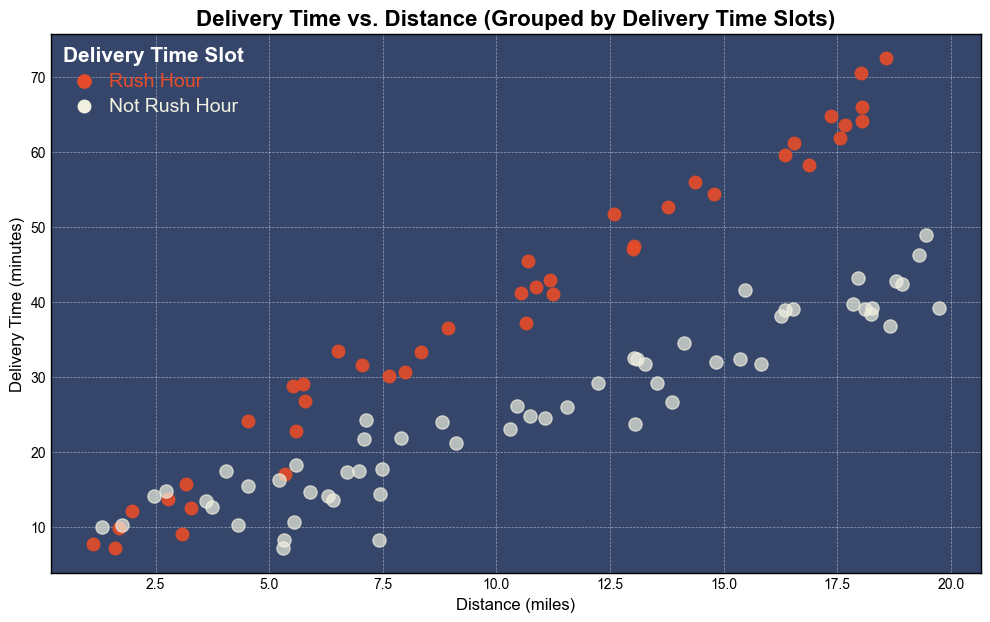

In [16]:
helper_funtions.plot_rush_hour(data_df,features)

__Prepared Data Plot__
* The cell below display the scatter plot that visualizes the data use for training the model. It will show Delivery Time vs. Normalized Distance.
* The points are styled by four categories, combining the day type and new rush hour feature.
* Note that "Weekend (Rush Hour)" does not appear, as feature correctly applies only to weekdays.

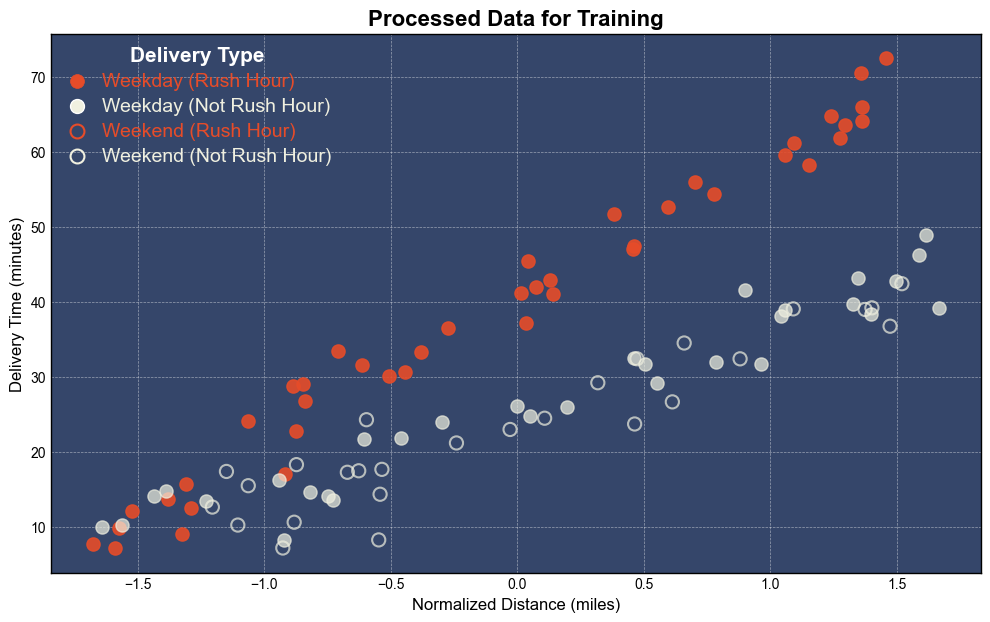

In [20]:
helper_funtions.plot_data(features,targets)

#### *2 - Building the Neural Network*
Implement the init_model function, to define the model architecture, the optimizer, and the loss function.

__Task__:

* __Define the Model Architecture__:
    * Define a model using nn.Sequential.
    * The model have three nn.Linear layers, each followed by a nn.ReLU() activation function, except for the last one.
        * __Input Layer__: An nn.Linear layer that accepts 4 input features and outputs 64 features.
        * __Hidden Layer__: An nn.Linear layer that takes the 64 features from the previous layer and outputs 32 features.
        * __Output Layer__: A final nn.Linear layer that takes the 32 features from the hidden layer and produces a single output value.
   
* __Define the Optimizer__:
    * Define the optimizer as Stochastic Gradient Descent (SGD).Pass it the model's parameters (model.parameters()) and set the learning rate (lr) to 0.01.
* __Define the Loss Function__:
    * Define the loss_function as Mean Squared Error (MSE).

In [23]:
def init_model():
    """
    Initializes the neural network model, optimizer, and loss function.

    Returns:
        model (nn.Sequential): The initialized PyTorch sequential model.
        optimizer (torch.optim.Optimizer): The initialized optimizer for training.
        loss_function: The initialized loss function.
    """

    # Set the random seed for reproducibility of results
    torch.manual_seed(41)

    # Define the model architecture using nn.Sequential
    model = nn.Sequential(
        # Input layer (Linear): 4 input features, 64 output features
        nn.Linear(4,64),
        # First ReLU activation function
        nn.ReLU(),
        # Hidden layer (Linear): 64 inputs, 32 outputs
        nn.Linear(64,32),
        # Second ReLU activation function
        nn.ReLU(),
        # Output layer (Linear): 32 inputs, 1 output (the prediction)
        nn.Linear(32,1)
    )

    # Define the optimizer (Stochastic Gradient Descent)
    optimizer = optim.SGD(params=model.parameters(),lr=0.01)

    # Define the loss function (Mean Squared Error for regression)
    loss_function = nn.MSELoss()

    return model, optimizer, loss_function

In [25]:
model,optimizer,loss_function = init_model()

print(f"{'='*50}\nInitialized Model Architecture\n{'='*50}\n{model}")
print(f"\n{'='*50}\nOptimizer\n{'='*50}\n{optimizer}")
print(f"\n{'='*50}\nLoss Function\n{'='*50}\n{loss_function}")

Initialized Model Architecture
Sequential(
  (0): Linear(in_features=4, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=32, bias=True)
  (3): ReLU()
  (4): Linear(in_features=32, out_features=1, bias=True)
)

Optimizer
SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)

Loss Function
MSELoss()


#### *3 - Training the Model*

Implement the complete training loop inside the train_model function.

__Task__:

* __Initialize model and tools__:
    * Start by calling the init_model() function built earlier to get model, optimizer, and loss_function.
* __Loop through the epochs__:
    * Create a for loop that iterates from 0 up to the number of epochs provided.
* __Implement the training steps inside the loop__:
    * Perform these five steps in order on each iteration:
        * __Forward Pass__: Pass features tensor into the model to get its predictions.
        * __Calculate Loss__: Use loss_function to compare the model's predictions with the actual targets.
        * __Zero Gradients__: Zero the gradients on the optimizer from the previous iteration.
        * __Backward Pass__: Perform the backward pass on loss to calculate the new gradients.
        * __Update Weights__: Take a step with the optimizer to update the model's parameters.

In [26]:
def train_model(features,targets,epochs,verbose = True):
    """
    Trains the model using the provided data for a number of epochs.

    Args:
        features (torch.Tensor): The input features for training.
        targets (torch.Tensor): The target values for training.
        epochs (int): The number of training epochs.
        verbose (bool): If True, prints training progress. Defaults to True.

    Returns:
        model (nn.Sequential): The trained model.
        losses (list): A list of loss values recorded every 5000 epochs.
    """

    # Initialize a list to store the loss
    losses = []

    # Initialize the model, optimizer, and loss function using `init_model`
    model, optimizer, loss_function = init_model()

    # Loop through the specified number of epochs
    for epoch in range(epochs):
        # Forward pass: Make predictions
        outputs = model(features)
        # Calculate the loss
        loss = loss_function(outputs,targets)
        # Zero the gradients
        optimizer.zero_grad()
        # Backward pass: Compute gradients
        loss.backward()
        # Update the model's parameters
        optimizer.step()

        # Every 5000 epochs, record the loss and print the progress
        if (epoch+1) % 5000 == 0:
            losses.append(loss.item())
            if verbose == True:
                print(f"Epoch [{epoch+1}/{epochs}],Loss: {loss.item():.4f}")

    return model, losses

In [27]:
# Training loop
model, loss = train_model(features=features,targets=targets,epochs=30000,verbose=True)

Epoch [5000/30000],Loss: 3.4232
Epoch [10000/30000],Loss: 1.8100
Epoch [15000/30000],Loss: 1.2015
Epoch [20000/30000],Loss: 0.7759
Epoch [25000/30000],Loss: 0.5330
Epoch [30000/30000],Loss: 0.2676


#### *4 - Evaluating Model Performance*
Now that model is trained, it's time to evaluate its performance. A simple yet powerful way to do this for a regression task is to plot the model's predictions against the actual target values.

* First, use trained model to get predictions for the entire dataset.
* Create a scatter plot, Actual Delivery Times (x-axis) vs. Predicted Delivery Times (y-axis).
* If the model is accurate, the points on the plot should form a tight cluster along a straight diagonal line.
    * The closer the points are to this line, the better the model's predictions are.

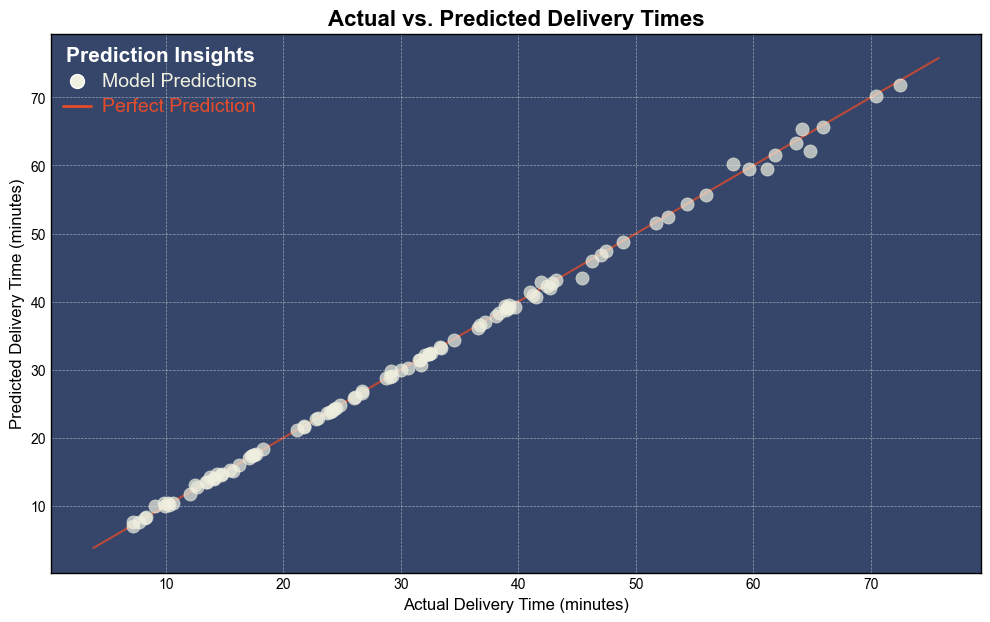

In [28]:
# Disable gradient calculation for efficient predictions
with torch.no_grad():
    # Perform a forward pass to get model predictions
    predicted_outputs = model(features)

# Plot predictions vs. actual targets to evaluate performance
helper_funtions.plot_model_predictions(predicted_outputs,targets)

The model's predictions (the light gray points) form a very tight cluster that follows the "Perfect Prediction" line almost exactly. This indicates that the model has learned the patterns in the data very well and is making highly accurate predictions.

#### *5 - Making a New Inferences*

In [29]:
# Set distance for the delivery in miles
distance_miles = 15.0
# Set time of day in 24-hour format (e.g., 9.5 for 9:30 AM)
time_of_day_hours = 10.0
# Use True/False or 1/0 to indicate if it's a weekend
is_weekend = True

# Convert the raw inputs into a 2D tensor for the model
raw_input_tensor = torch.tensor([[distance_miles,time_of_day_hours,is_weekend]],dtype=torch.float32)

In [30]:
helper_funtions.prediction(model,data_df,raw_input_tensor,rush_hour_feature)

+------------------------------------------+-----------------------+
|                         Model Prediction                         |
+------------------------------------------+-----------------------+
| Time of the Week                         | Weekend               |
| Distance                                 | 15.0 miles            |
| Time                                     | 10:00                 |
| Is this considered a rush hour period?   | No                    |
+------------------------------------------+-----------------------+
| Estimated Delivery Time                  | 30.43 minutes         |
+------------------------------------------+-----------------------+
